# Five-fold CNN comparison with early stopping

This notebook compares the spatial and radial Landsat LST inputs across all five deterministic Statbel-sector test folds. Every outer fold receives a separate sector-held-out validation partition and a second 200 m embargo. Validation controls only the stopping epoch; each outer test fold is evaluated once after the best in-memory model state is restored.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

PROJECT_ROOT = Path.cwd().resolve()
if not (PROJECT_ROOT / 'processing' / 'local-layers').exists():
    PROJECT_ROOT = PROJECT_ROOT.parent.resolve()
PACKAGE_ROOT = PROJECT_ROOT / 'processing' / 'local-layers'
if str(PACKAGE_ROOT / 'src') not in sys.path:
    sys.path.insert(0, str(PACKAGE_ROOT / 'src'))

from greenwave_local_layers.image_regression import (
    DEFAULT_OBSERVATION_ID, load_regression_catalog, make_sector_folds,
)
from greenwave_local_layers.image_regression_training import (
    EarlyStoppingConfig, LSTRegressionCNN, TrainingConfig,
    count_trainable_parameters, make_sector_validation_split,
    pooled_regression_metrics, train_with_early_stopping,
)

plt.style.use('seaborn-v0_8-whitegrid')
pd.set_option('display.max_columns', 30)

## Leakage-safe outer and inner folds

The outer folds hold out complete test sectors. Within each outer training set, complete sectors representing approximately 15% of candidate samples form the validation set. Fitting centres within 200 m of either validation or outer-test sector geometry are excluded.

In [2]:
catalog = load_regression_catalog(DEFAULT_OBSERVATION_ID)
outer_folds = make_sector_folds(catalog.samples, n_splits=5, buffer_m=200, seed=42)
inner_splits = tuple(
    make_sector_validation_split(
        catalog.samples, outer_fold, validation_fraction=0.15, buffer_m=200, seed=42,
    )
    for outer_fold in outer_folds
)
config = TrainingConfig()
stopping = EarlyStoppingConfig(max_epochs=50, patience=5, min_delta=1e-4)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

split_rows = []
for outer_fold, inner_split in zip(outer_folds, inner_splits):
    outer_sets = [
        set(outer_fold.train_indices), set(outer_fold.test_indices),
        set(outer_fold.excluded_buffer_indices),
    ]
    inner_sets = [
        set(inner_split.fit_indices), set(inner_split.validation_indices),
        set(inner_split.excluded_buffer_indices),
    ]
    assert inner_split.outer_fold == outer_fold.fold
    assert set.union(*inner_sets) == set(outer_fold.train_indices)
    assert all(inner_sets[a].isdisjoint(inner_sets[b]) for a, b in ((0, 1), (0, 2), (1, 2)))
    assert all(values.isdisjoint(outer_sets[1]) for values in inner_sets)
    split_rows.append({
        'fold': outer_fold.fold,
        'outer candidates': len(outer_fold.train_indices),
        'fit': len(inner_split.fit_indices),
        'validation': len(inner_split.validation_indices),
        'inner embargo': len(inner_split.excluded_buffer_indices),
        'outer test': len(outer_fold.test_indices),
        'outer embargo': len(outer_fold.excluded_buffer_indices),
        'fit sectors': len(inner_split.fit_sector_ids),
        'validation sectors': len(inner_split.validation_sector_ids),
        'test sectors': len(outer_fold.test_sector_ids),
        'validation fraction': inner_split.diagnostics['validationFractionBeforeBuffer'],
    })
split_table = pd.DataFrame(split_rows).set_index('fold')
display(split_table.round({'validation fraction': 4}))

runtime_summary = pd.Series({
    'observation': catalog.observation_id,
    'samples': len(catalog.samples),
    'outer folds': len(outer_folds),
    'device': str(device),
    'PyTorch': torch.__version__,
    'CUDA runtime': torch.version.cuda or 'not available',
    'GPU': torch.cuda.get_device_name(0) if torch.cuda.is_available() else 'CPU fallback',
    'maximum epochs': stopping.max_epochs,
    'patience': stopping.patience,
    'minimum improvement': stopping.min_delta,
    'batch size': config.batch_size,
    'learning rate': config.learning_rate,
    'weight decay': config.weight_decay,
    'dropout': config.dropout,
    'loader workers': config.num_workers,
    'AMP enabled': bool(config.amp and torch.cuda.is_available()),
    'trainable parameters': count_trainable_parameters(LSTRegressionCNN(dropout=config.dropout)),
})
display(runtime_summary.to_frame('value'))

,outer candidates,fit,validation,inner embargo,outer test,outer embargo,fit sectors,validation sectors,test sectors,validation fraction
fold,,,,,,,,,,
0,9602,7172,1441,989,3078,2709,93,15,28,0.1501
1,10274,7291,1542,1441,3078,2037,95,15,28,0.1501
2,9254,6839,1389,1026,3078,3057,90,14,30,0.1501
3,9245,6664,1387,1194,3077,3067,94,15,30,0.1500
4,9283,6976,1393,914,3078,3028,92,15,30,0.1501


,value
observation,landsat-2026-06-22
samples,15389
outer folds,5
device,cuda
PyTorch,2.12.1+cu130
CUDA runtime,13.0
GPU,NVIDIA GeForce RTX 5070 Ti
maximum epochs,50
patience,5
minimum improvement,0.0001


## Spatial models

Each fold starts from seed 42. Only fitting patches receive random right-angle rotations and mirrors.

In [3]:
spatial_results = []
for outer_fold, inner_split in zip(outer_folds, inner_splits):
    print(f"\n=== spatial outer fold {outer_fold.fold} ===", flush=True)
    result = train_with_early_stopping(
        catalog, outer_fold, inner_split, representation='spatial',
        config=config, stopping=stopping, augment_spatial=True,
        device=device, verbose=True,
    )
    assert np.array_equal(result.catalog_indices, outer_fold.test_indices)
    spatial_results.append(result)
    print(
        f"fold {outer_fold.fold} spatial: best epoch {result.best_epoch}, "
        f"stopped {result.stopped_epoch}, metrics {result.metrics}", flush=True,
    )


=== spatial outer fold 0 ===


fold 0 spatial epoch 01/50: train MSE = 0.30987, validation MSE = 0.85142 *


fold 0 spatial epoch 02/50: train MSE = 0.27710, validation MSE = 0.43735 *


fold 0 spatial epoch 03/50: train MSE = 0.26656, validation MSE = 0.34364 *


fold 0 spatial epoch 04/50: train MSE = 0.25409, validation MSE = 0.36068


...

fold 4 spatial epoch 05/50: train MSE = 0.37333, validation MSE = 0.87330


fold 4 spatial epoch 06/50: train MSE = 0.35891, validation MSE = 0.73171


fold 4 spatial epoch 07/50: train MSE = 0.35953, validation MSE = 0.69334


fold 4 spatial epoch 08/50: train MSE = 0.34586, validation MSE = 0.60433


fold 4 spatial: best epoch 3, stopped 8, metrics {'count': 3078, 'mae_c': 2.1916443754745196, 'rmse_c': 2.7693216057799472, 'r2': 0.4648361359636547, 'mean_error_c': -0.17026676862095763}


## Radial models

The same fold partitions, architecture, seed, and optimization settings are reused. Radial axes encode distance and fraction, so no rotations or mirrors are applied.

In [4]:
radial_results = []
for outer_fold, inner_split in zip(outer_folds, inner_splits):
    print(f"\n=== radial outer fold {outer_fold.fold} ===", flush=True)
    result = train_with_early_stopping(
        catalog, outer_fold, inner_split, representation='radial',
        config=config, stopping=stopping, augment_spatial=False,
        device=device, verbose=True,
    )
    assert np.array_equal(result.catalog_indices, outer_fold.test_indices)
    radial_results.append(result)
    print(
        f"fold {outer_fold.fold} radial: best epoch {result.best_epoch}, "
        f"stopped {result.stopped_epoch}, metrics {result.metrics}", flush=True,
    )


=== radial outer fold 0 ===


fold 0 radial epoch 01/50: train MSE = 0.35066, validation MSE = 0.82750 *


fold 0 radial epoch 02/50: train MSE = 0.29410, validation MSE = 0.48814 *


fold 0 radial epoch 03/50: train MSE = 0.28881, validation MSE = 0.55479


fold 0 radial epoch 04/50: train MSE = 0.27709, validation MSE = 0.51045


...

fold 4 radial epoch 13/50: train MSE = 0.08936, validation MSE = 1.13398


fold 4 radial epoch 14/50: train MSE = 0.07451, validation MSE = 1.53600


fold 4 radial epoch 15/50: train MSE = 0.06065, validation MSE = 1.66094


fold 4 radial epoch 16/50: train MSE = 0.05419, validation MSE = 0.94220


fold 4 radial: best epoch 11, stopped 16, metrics {'count': 3078, 'mae_c': 2.5607252213922393, 'rmse_c': 3.1201189005178898, 'r2': 0.32066767331095936, 'mean_error_c': -1.2164118669496256}


## Per-fold and aggregated held-out results

In [5]:
results_by_pipeline = {'Spatial': spatial_results, 'Radial': radial_results}
expected_indices = np.arange(len(catalog.samples), dtype=np.int64)
for spatial_result, radial_result, outer_fold in zip(
        spatial_results, radial_results, outer_folds):
    assert np.array_equal(spatial_result.catalog_indices, radial_result.catalog_indices)
    assert np.array_equal(spatial_result.catalog_indices, outer_fold.test_indices)
    assert np.allclose(spatial_result.targets_c, radial_result.targets_c)
for pipeline, results in results_by_pipeline.items():
    indices = np.concatenate([result.catalog_indices for result in results])
    targets = np.concatenate([result.targets_c for result in results])
    assert len(np.unique(indices)) == len(catalog.samples)
    assert np.array_equal(np.sort(indices), expected_indices)
    assert np.allclose(targets, catalog.samples.iloc[indices]['lst_c'].to_numpy())

per_fold_rows = []
for pipeline, results in results_by_pipeline.items():
    for result, outer_fold, inner_split in zip(results, outer_folds, inner_splits):
        per_fold_rows.append({
            'pipeline': pipeline, 'fold': result.outer_fold,
            'fit': len(inner_split.fit_indices),
            'validation': len(inner_split.validation_indices),
            'inner embargo': len(inner_split.excluded_buffer_indices),
            'test': len(outer_fold.test_indices),
            'best epoch': result.best_epoch, 'stopped epoch': result.stopped_epoch,
            'MAE (°C)': result.metrics['mae_c'],
            'RMSE (°C)': result.metrics['rmse_c'],
            'R²': result.metrics['r2'],
            'Mean signed error (°C)': result.metrics['mean_error_c'],
        })
per_fold_table = pd.DataFrame(per_fold_rows).set_index(['pipeline', 'fold'])
display(per_fold_table.round(4))

fit  validation  inner embargo  test  best epoch  \
pipeline fold                                                      
Spatial  0     7172        1441            989  3078           3   
         1     7291        1542           1441  3078           4   
         2     6839        1389           1026  3078           4   
         3     6664        1387           1194  3077           9   
         4     6976        1393            914  3078           3   
Radial   0     7172        1441            989  3078           6   
         1     7291        1542           1441  3078           4   
         2     6839        1389           1026  3078           3   
         3     6664        1387           1194  3077           2   
         4     6976        1393            914  3078          11   

               stopped epoch  MAE (°C)  RMSE (°C)      R²  \
pipeline fold                                               
Spatial  0                 8    1.8105     2.2670 -0.0540   
         1                 9    1.9527     2.3653  0.5313   
         2                 9    1.9074     2.5056  0.4884   
         3                14    1.8456     2.3517  0.5492   
         4                 8    2.1916     2.7693  0.4648   
Radial   0                11    2.0531     2.4866 -0.2681   
         1                 9    2.5893     3.0080  0.2421   
         2                 8    1.9828     2.5863  0.4549   
         3                 7    1.6922     2.1043  0.6390   
         4                16    2.5607     3.1201  0.3207   

               Mean signed error (°C)  
pipeline fold                          
Spatial  0                     0.0460  
         1                    -1.2651  
         2                     0.7661  
         3                     0.1717  
         4                    -0.1703  
Radial   0                    -0.5382  
         1                    -2.2900  
         2                     0.7302  
         3                    -0.1382  
         4                    -1.2164

In [6]:
metric_columns = ['MAE (°C)', 'RMSE (°C)', 'R²', 'Mean signed error (°C)']
macro_table = per_fold_table.groupby(level='pipeline')[metric_columns].agg(['mean', 'std'])
display(macro_table.round(4))

pooled_rows = []
for pipeline, results in results_by_pipeline.items():
    metrics = pooled_regression_metrics(results)
    pooled_rows.append({
        'pipeline': pipeline, 'samples': metrics['count'],
        'MAE (°C)': metrics['mae_c'], 'RMSE (°C)': metrics['rmse_c'],
        'R²': metrics['r2'], 'Mean signed error (°C)': metrics['mean_error_c'],
        'mean best epoch': np.mean([result.best_epoch for result in results]),
        'mean stopped epoch': np.mean([result.stopped_epoch for result in results]),
    })
pooled_table = pd.DataFrame(pooled_rows).set_index('pipeline')
display(pooled_table.round(4))

MAE (°C)         RMSE (°C)              R²          \
             mean     std      mean     std    mean     std   
pipeline                                                      
Radial     2.1756  0.3890    2.6611  0.4114  0.2777  0.3402   
Spatial    1.9416  0.1502    2.4518  0.1971  0.3959  0.2538   

         Mean signed error (°C)          
                           mean     std  
pipeline                                 
Radial                  -0.6905  1.1382  
Spatial                 -0.0903  0.7428

,samples,MAE (°C),RMSE (°C),R²,Mean signed error (°C),mean best epoch,mean stopped epoch
pipeline,,,,,,,
Spatial,15389,1.9416,2.4581,0.4927,-0.0903,4.6,9.6
Radial,15389,2.1757,2.6864,0.3941,-0.6906,5.2,10.2


## Learning curves

Stars in the training log identify validation improvements. Dashed vertical lines below show the restored best epoch.

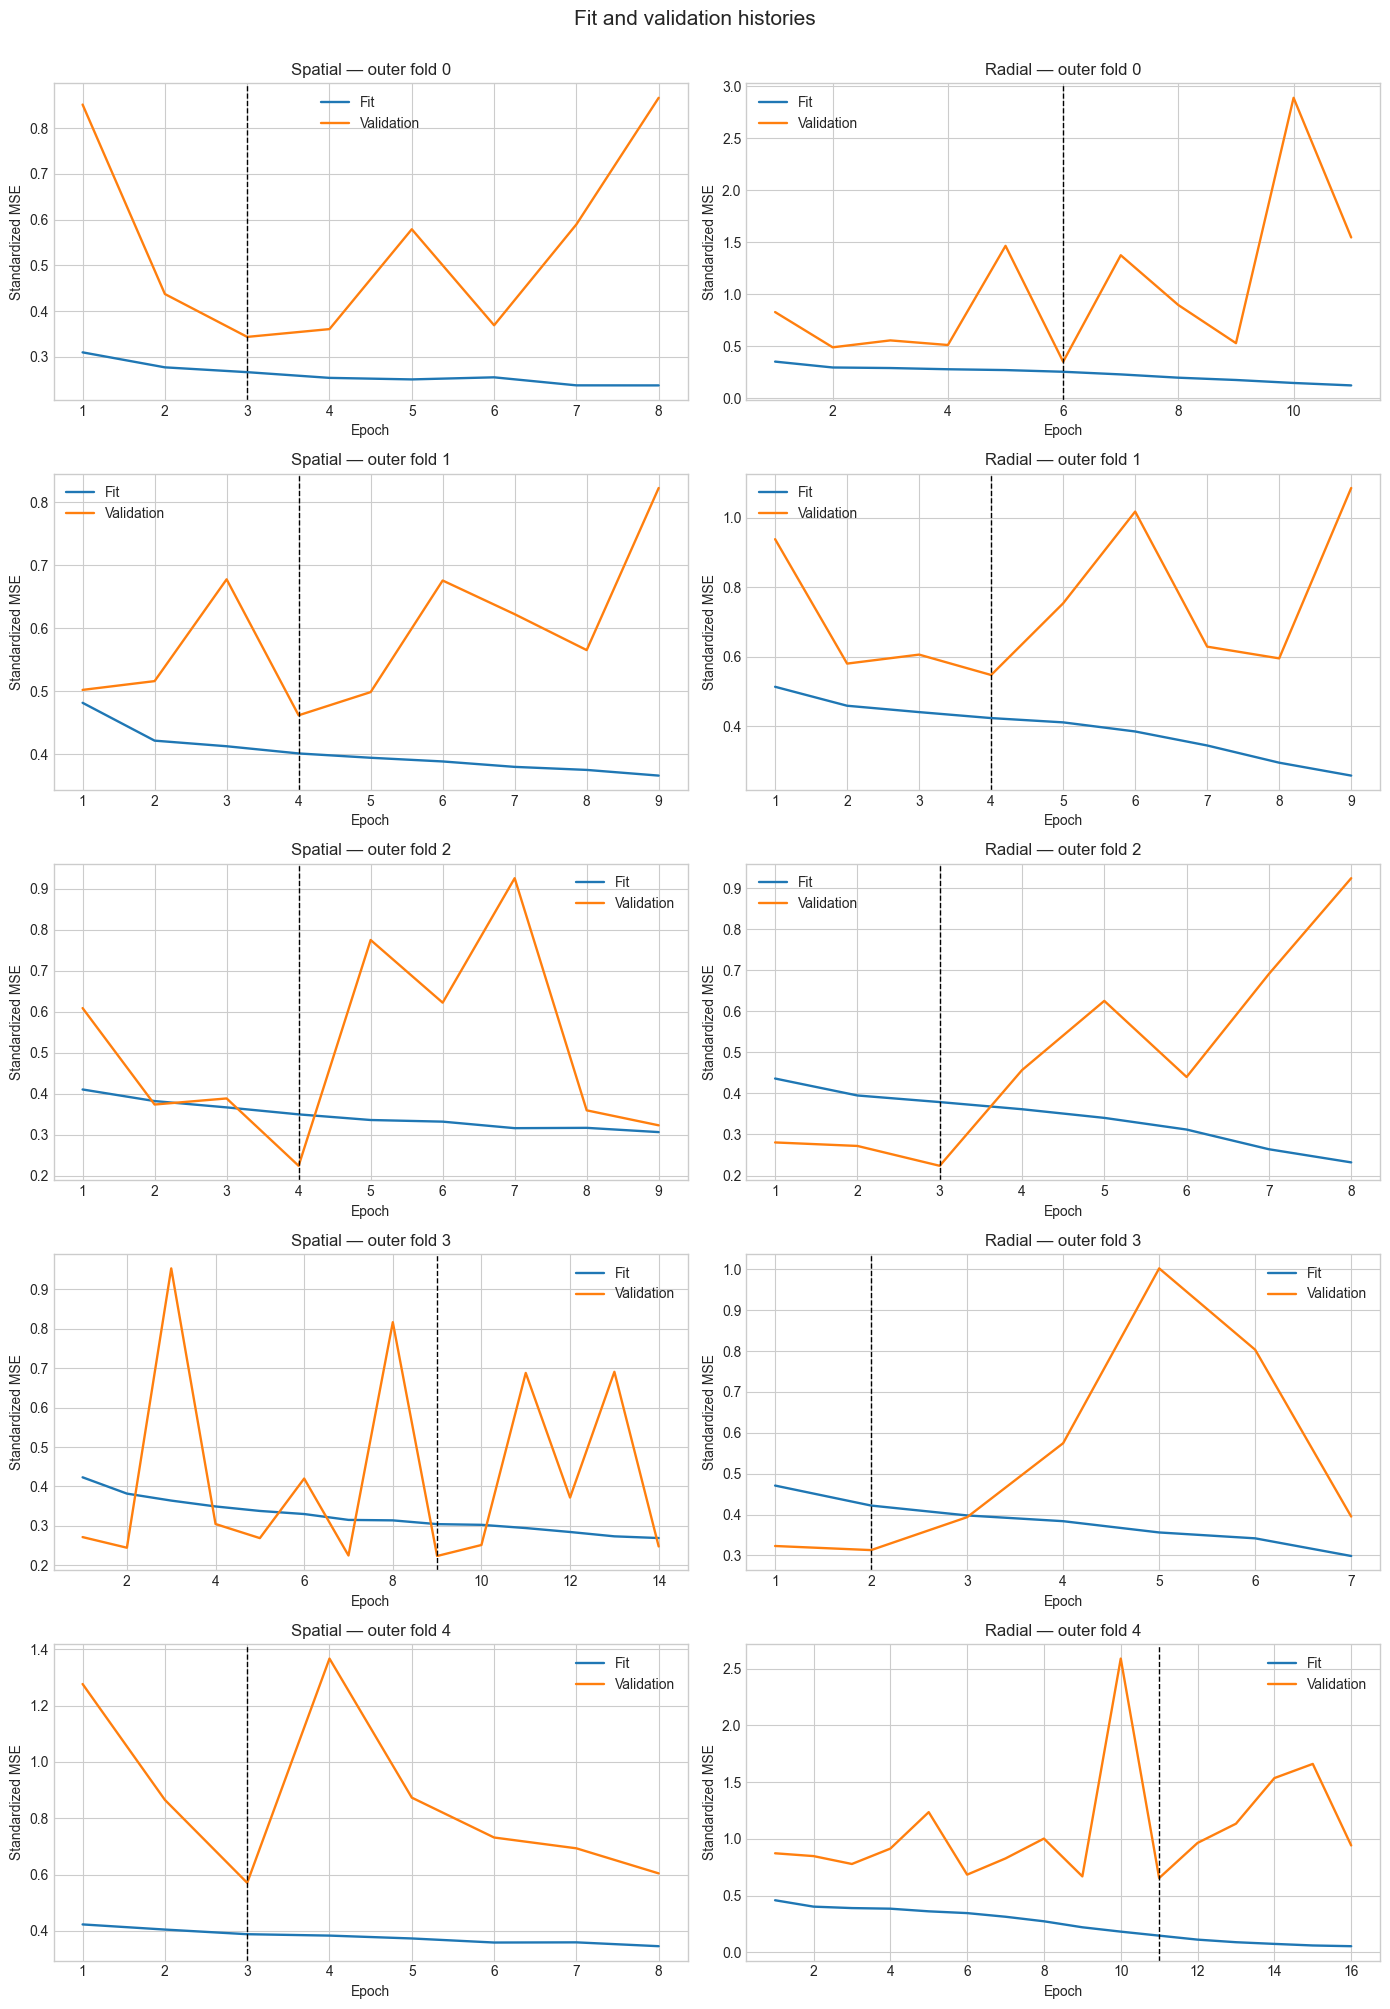

In [7]:
fig, axes = plt.subplots(5, 2, figsize=(14, 20), sharex=False)
for column, (pipeline, results) in enumerate(results_by_pipeline.items()):
    for row, result in enumerate(results):
        epochs = [item['epoch'] for item in result.history]
        axes[row, column].plot(
            epochs, [item['train_mse_standardized'] for item in result.history],
            label='Fit', linewidth=1.7,
        )
        axes[row, column].plot(
            epochs, [item['validation_mse_standardized'] for item in result.history],
            label='Validation', linewidth=1.7,
        )
        axes[row, column].axvline(result.best_epoch, color='black', linestyle='--', linewidth=1)
        axes[row, column].set(
            title=f'{pipeline} — outer fold {row}', xlabel='Epoch',
            ylabel='Standardized MSE',
        )
        axes[row, column].legend()
fig.suptitle('Fit and validation histories', y=1.002, fontsize=15)
plt.tight_layout()
plt.show()

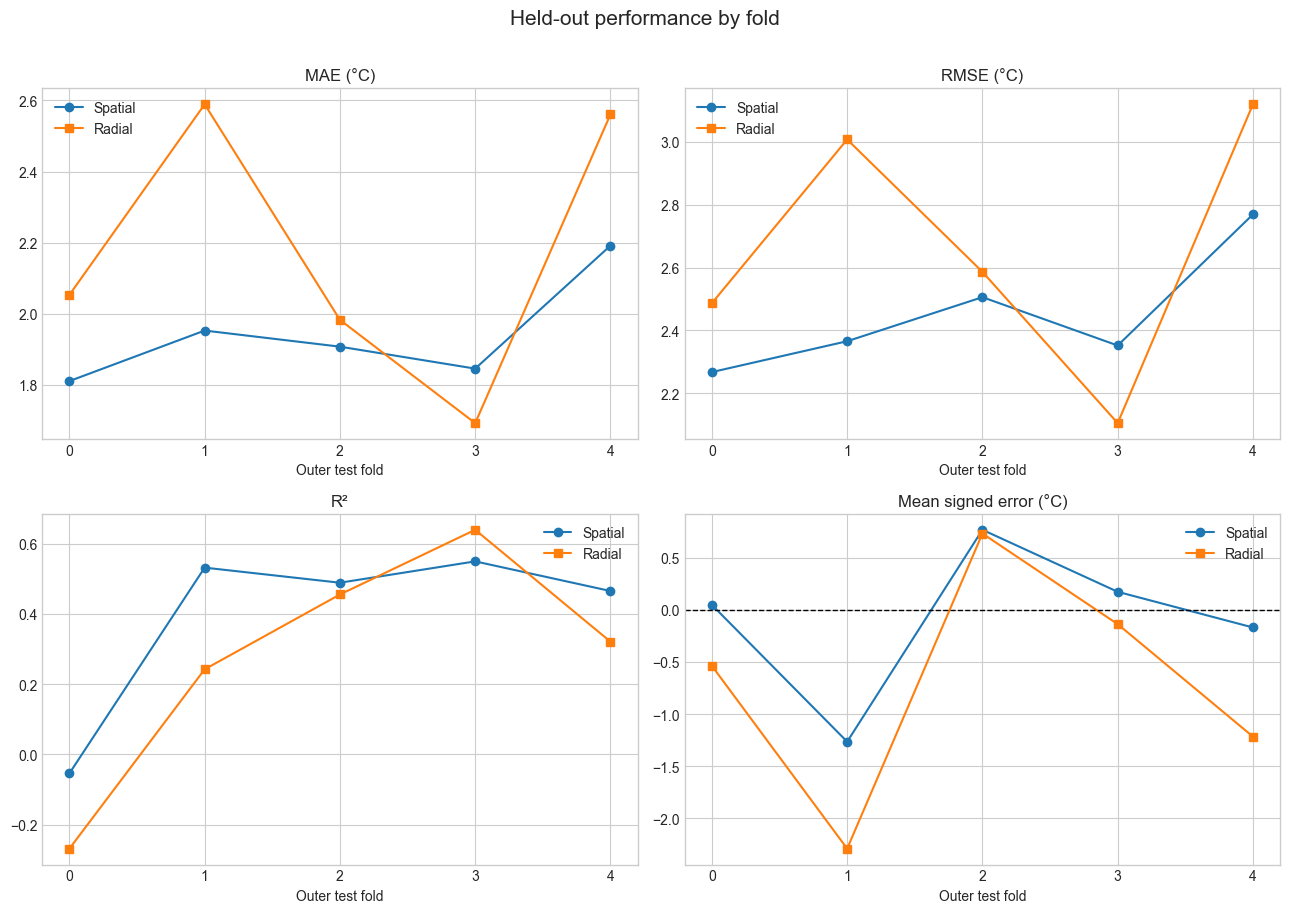

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))
for ax, metric in zip(axes.flat, metric_columns):
    for pipeline, marker in [('Spatial', 'o'), ('Radial', 's')]:
        values = per_fold_table.loc[pipeline][metric].to_numpy()
        ax.plot(range(5), values, marker=marker, linewidth=1.5, label=pipeline)
    if metric == 'Mean signed error (°C)':
        ax.axhline(0, color='black', linestyle='--', linewidth=1)
    ax.set(title=metric, xlabel='Outer test fold', xticks=range(5))
    ax.legend()
fig.suptitle('Held-out performance by fold', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

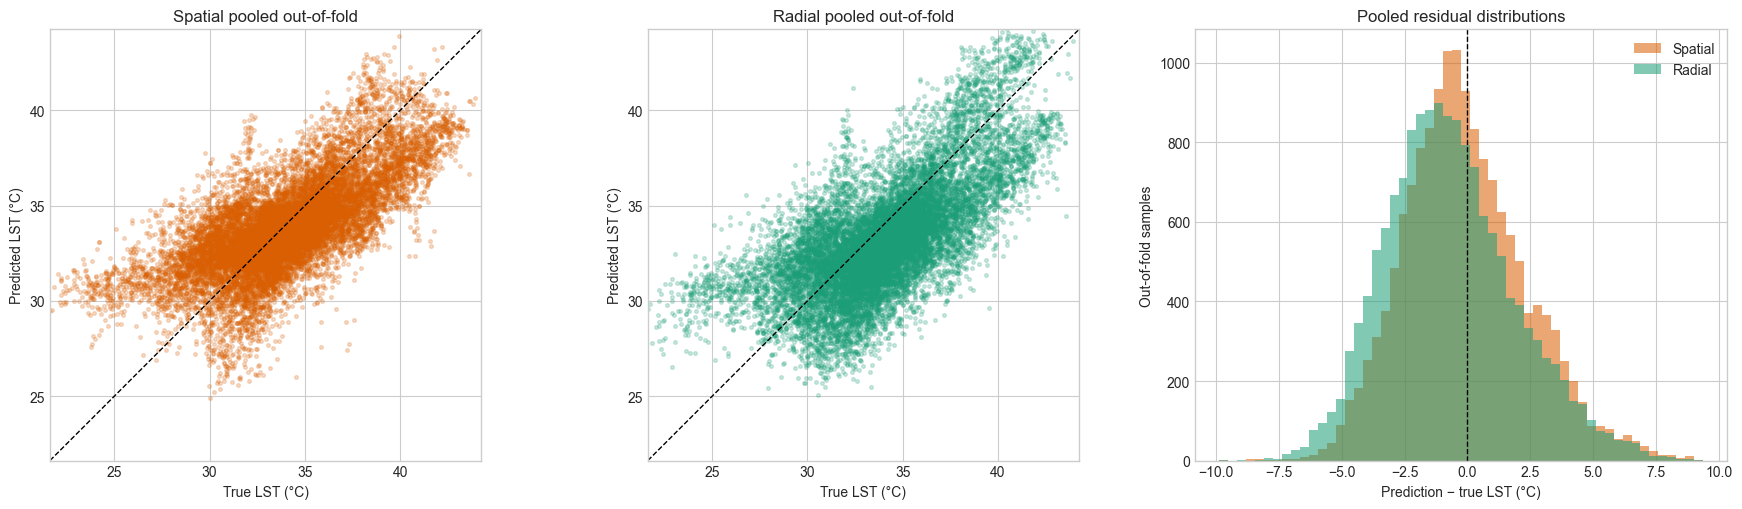

In [9]:
pooled_arrays = {}
for pipeline, results in results_by_pipeline.items():
    pooled_arrays[pipeline] = {
        'targets': np.concatenate([result.targets_c for result in results]),
        'predictions': np.concatenate([result.predictions_c for result in results]),
    }
all_values = np.concatenate([
    pooled_arrays[pipeline][kind]
    for pipeline in pooled_arrays for kind in ('targets', 'predictions')
])
plot_min, plot_max = float(all_values.min()), float(all_values.max())
fig, axes = plt.subplots(1, 3, figsize=(18, 5.2))
for ax, (pipeline, color) in zip(axes[:2], [('Spatial', '#d95f02'), ('Radial', '#1b9e77')]):
    targets = pooled_arrays[pipeline]['targets']
    predictions = pooled_arrays[pipeline]['predictions']
    ax.scatter(targets, predictions, s=7, alpha=0.22, color=color)
    ax.plot([plot_min, plot_max], [plot_min, plot_max], 'k--', linewidth=1)
    ax.set(
        title=f'{pipeline} pooled out-of-fold', xlabel='True LST (°C)',
        ylabel='Predicted LST (°C)', xlim=(plot_min, plot_max), ylim=(plot_min, plot_max),
    )
    ax.set_aspect('equal', adjustable='box')
residual_min = min(
    (values['predictions'] - values['targets']).min() for values in pooled_arrays.values()
)
residual_max = max(
    (values['predictions'] - values['targets']).max() for values in pooled_arrays.values()
)
bins = np.linspace(residual_min, residual_max, 55)
for pipeline, color in [('Spatial', '#d95f02'), ('Radial', '#1b9e77')]:
    values = pooled_arrays[pipeline]
    axes[2].hist(
        values['predictions'] - values['targets'], bins=bins, alpha=0.55,
        label=pipeline, color=color,
    )
axes[2].axvline(0, color='black', linestyle='--', linewidth=1)
axes[2].set(
    title='Pooled residual distributions', xlabel='Prediction − true LST (°C)',
    ylabel='Out-of-fold samples',
)
axes[2].legend()
plt.tight_layout()
plt.show()

In [10]:
print(
    f"Completed {len(spatial_results)} spatial and {len(radial_results)} radial models on {device}. "
    f"Each pipeline produced exactly {len(catalog.samples):,} unique out-of-fold predictions."
)

Completed 5 spatial and 5 radial models on cuda. Each pipeline produced exactly 15,389 unique out-of-fold predictions.


## XGBoost on four radial distance bands

The radial data are now collapsed into four area-weighted quantities per channel: active 1 m pixels divided by valid pixels in `[0, 25)`, `[25, 50)`, `[50, 75)`, and `[75, 100)` metres. This produces 12 bounded tabular features: four each for sealed soil, high green, and water. The exact outer test folds and leakage-safe inner validation splits used above are retained.

In [11]:
import time
import xgboost as xgb

from greenwave_local_layers.image_regression import (
    CHANNEL_NAMES, ImageRegressionDataset, RADIAL_BAND_EDGES_METERS,
    radial_band_fractions,
)
from greenwave_local_layers.image_regression_xgboost import (
    XGBoostConfig, train_xgboost_fold,
)

xgb_config = XGBoostConfig(
    num_boost_round=2_000, early_stopping_rounds=50, learning_rate=0.05,
    max_depth=4, min_child_weight=1.0, subsample=0.8,
    colsample_bytree=0.8, reg_alpha=0.0, reg_lambda=1.0, seed=42,
)
xgb_device = 'cuda' if torch.cuda.is_available() else 'cpu'
radial_bands = tuple(zip(RADIAL_BAND_EDGES_METERS[:-1], RADIAL_BAND_EDGES_METERS[1:]))
feature_names = tuple(
    f'{channel}_{lower}_{upper}m'
    for channel in CHANNEL_NAMES for lower, upper in radial_bands
)
display(pd.Series({
    'XGBoost': xgb.__version__, 'device': xgb_device,
    'feature count': len(feature_names), 'maximum boosting rounds': xgb_config.num_boost_round,
    'early-stopping rounds': xgb_config.early_stopping_rounds,
    'learning rate': xgb_config.learning_rate, 'maximum depth': xgb_config.max_depth,
    'subsample': xgb_config.subsample, 'column sample': xgb_config.colsample_bytree,
}).to_frame('value'))
feature_names

,value
XGBoost,3.2.0
device,cuda
feature count,12
maximum boosting rounds,2000
early-stopping rounds,50
learning rate,0.05
maximum depth,4
subsample,0.8
column sample,0.8


('soil_sealing_0_25m',
 'soil_sealing_25_50m',
 'soil_sealing_50_75m',
 'soil_sealing_75_100m',
 'high_green_0_25m',
 'high_green_25_50m',
 'high_green_50_75m',
 'high_green_75_100m',
 'water_0_25m',
 'water_25_50m',
 'water_50_75m',
 'water_75_100m')

In [12]:
started = time.perf_counter()
radial_band_features = np.empty((len(catalog.samples), len(feature_names)), dtype=np.float32)
feature_dataset = ImageRegressionDataset(catalog, representation='spatial')
try:
    for catalog_index in range(len(catalog.samples)):
        radial_band_features[catalog_index] = radial_band_fractions(
            feature_dataset.spatial_patch(catalog_index)
        ).reshape(-1)
        if (catalog_index + 1) % 2_000 == 0:
            print(f'extracted {catalog_index + 1:,}/{len(catalog.samples):,} samples', flush=True)
finally:
    feature_dataset.close()
assert radial_band_features.shape == (len(catalog.samples), 12)
assert np.all(np.isfinite(radial_band_features))
assert np.all((0 <= radial_band_features) & (radial_band_features <= 1))
print(f'Feature extraction completed in {time.perf_counter() - started:.1f} seconds.')
display(pd.DataFrame(radial_band_features, columns=feature_names).describe().round(4))

extracted 2,000/15,389 samples


extracted 4,000/15,389 samples


extracted 6,000/15,389 samples


extracted 8,000/15,389 samples


extracted 10,000/15,389 samples


extracted 12,000/15,389 samples


extracted 14,000/15,389 samples


Feature extraction completed in 27.6 seconds.


,soil_sealing_0_25m,soil_sealing_25_50m,soil_sealing_50_75m,soil_sealing_75_100m,high_green_0_25m,high_green_25_50m,high_green_50_75m,high_green_75_100m,water_0_25m,water_25_50m,water_50_75m,water_75_100m
count,15389.0000,15389.0000,15389.0000,15389.0000,15389.0000,15389.0000,15389.0000,15389.0000,15389.0000,15389.0000,15389.0000,15389.0000
mean,0.5879,0.4743,0.4202,0.3946,0.1190,0.1627,0.1807,0.1887,0.0002,0.0007,0.0014,0.0023
std,0.2114,0.1942,0.1913,0.1921,0.1450,0.1517,0.1498,0.1485,0.0078,0.0140,0.0190,0.0227
min,0.0071,0.0042,0.0060,0.0020,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000,0.0000
25%,0.4322,0.3340,0.2802,0.2488,0.0157,0.0503,0.0688,0.0759,0.0000,0.0000,0.0000,0.0000
50%,0.5876,0.4646,0.3982,0.3706,0.0617,0.1127,0.1336,0.1445,0.0000,0.0000,0.0000,0.0000
75%,0.7490,0.6050,0.5461,0.5234,0.1685,0.2316,0.2540,0.2649,0.0000,0.0000,0.0000,0.0000
max,1.0000,1.0000,0.9980,0.9897,1.0000,0.9375,0.9992,0.9297,0.5369,0.6490,0.5630,0.4829


In [13]:
raw_targets_c = catalog.samples['lst_c'].to_numpy(dtype=np.float32)
xgb_results = []
for outer_fold, inner_split in zip(outer_folds, inner_splits):
    print(f"\n=== XGBoost outer fold {outer_fold.fold} ===", flush=True)
    result = train_xgboost_fold(
        radial_band_features, raw_targets_c, outer_fold, inner_split,
        feature_names, xgb_config, device=xgb_device, verbose=True,
    )
    assert np.array_equal(result.catalog_indices, outer_fold.test_indices)
    assert np.array_equal(result.fit_indices, inner_split.fit_indices)
    assert np.array_equal(result.validation_indices, inner_split.validation_indices)
    xgb_results.append(result)
    print(
        f"fold {outer_fold.fold}: best round {result.best_round}, "
        f"stopped {result.stopped_round}, metrics {result.metrics}", flush=True,
    )


=== XGBoost outer fold 0 ===


[0]	fit-rmse:3.67137	validation-rmse:4.79671


[100]	fit-rmse:1.88495	validation-rmse:2.50130


[148]	fit-rmse:1.84240	validation-rmse:2.50381


fold 0: best round 99, stopped 149, metrics {'count': 3078, 'mae_c': 1.9549202661842708, 'rmse_c': 2.4711449700304677, 'r2': -0.2524019400000439, 'mean_error_c': 0.34148352079534006}


...

[0]	fit-rmse:3.11302	validation-rmse:4.20684


[100]	fit-rmse:1.89460	validation-rmse:2.83340


[200]	fit-rmse:1.82013	validation-rmse:2.82228


[228]	fit-rmse:1.80000	validation-rmse:2.82316


fold 4: best round 179, stopped 229, metrics {'count': 3078, 'mae_c': 1.9497884703271182, 'rmse_c': 2.6358785289995366, 'r2': 0.5151685567402842, 'mean_error_c': 0.6563856677624836}


In [14]:
xgb_indices = np.concatenate([result.catalog_indices for result in xgb_results])
xgb_targets = np.concatenate([result.targets_c for result in xgb_results])
xgb_predictions = np.concatenate([result.predictions_c for result in xgb_results])
assert len(np.unique(xgb_indices)) == len(catalog.samples)
assert np.array_equal(np.sort(xgb_indices), np.arange(len(catalog.samples)))
assert np.allclose(xgb_targets, raw_targets_c[xgb_indices])

xgb_fold_rows = []
for result, outer_fold, inner_split in zip(xgb_results, outer_folds, inner_splits):
    xgb_fold_rows.append({
        'fold': result.outer_fold, 'fit': len(inner_split.fit_indices),
        'validation': len(inner_split.validation_indices),
        'inner embargo': len(inner_split.excluded_buffer_indices),
        'test': len(outer_fold.test_indices), 'best round': result.best_round,
        'stopped round': result.stopped_round,
        'MAE (°C)': result.metrics['mae_c'], 'RMSE (°C)': result.metrics['rmse_c'],
        'R²': result.metrics['r2'],
        'Mean signed error (°C)': result.metrics['mean_error_c'],
    })
xgb_fold_table = pd.DataFrame(xgb_fold_rows).set_index('fold')
display(xgb_fold_table.round(4))
display(xgb_fold_table[metric_columns].agg(['mean', 'std']).round(4))

xgb_pooled = pooled_regression_metrics(xgb_results)
three_model_pooled = pooled_table.copy()
three_model_pooled.loc['XGBoost radial bands'] = {
    'samples': xgb_pooled['count'], 'MAE (°C)': xgb_pooled['mae_c'],
    'RMSE (°C)': xgb_pooled['rmse_c'], 'R²': xgb_pooled['r2'],
    'Mean signed error (°C)': xgb_pooled['mean_error_c'],
    'mean best epoch': np.mean([result.best_round for result in xgb_results]),
    'mean stopped epoch': np.mean([result.stopped_round for result in xgb_results]),
}
three_model_pooled = three_model_pooled.rename(columns={
    'mean best epoch': 'mean best epoch/round',
    'mean stopped epoch': 'mean stopped epoch/round',
})
display(three_model_pooled.round(4))

,fit,validation,inner embargo,test,best round,stopped round,MAE (°C),RMSE (°C),R²,Mean signed error (°C)
fold,,,,,,,,,,
0,7172,1441,989,3078,99,149,1.9549,2.4711,-0.2524,0.3415
1,7291,1542,1441,3078,79,129,1.7448,2.1166,0.6247,-0.9691
2,6839,1389,1026,3078,71,121,1.9371,2.3829,0.5373,-0.2429
3,6664,1387,1194,3077,22,72,1.7439,2.1272,0.6311,-0.1571
4,6976,1393,914,3078,179,229,1.9498,2.6359,0.5152,0.6564


,MAE (°C),RMSE (°C),R²,Mean signed error (°C)
mean,1.8661,2.3467,0.4112,-0.0742
std,0.1113,0.2245,0.3745,0.6210


,samples,MAE (°C),RMSE (°C),R²,Mean signed error (°C),mean best epoch/round,mean stopped epoch/round
pipeline,,,,,,,
Spatial,15389,1.9416,2.4581,0.4927,-0.0903,4.6,9.6
Radial,15389,2.1757,2.6864,0.3941,-0.6906,5.2,10.2
XGBoost radial bands,15389,1.8661,2.3553,0.5342,-0.0742,90.0,140.0


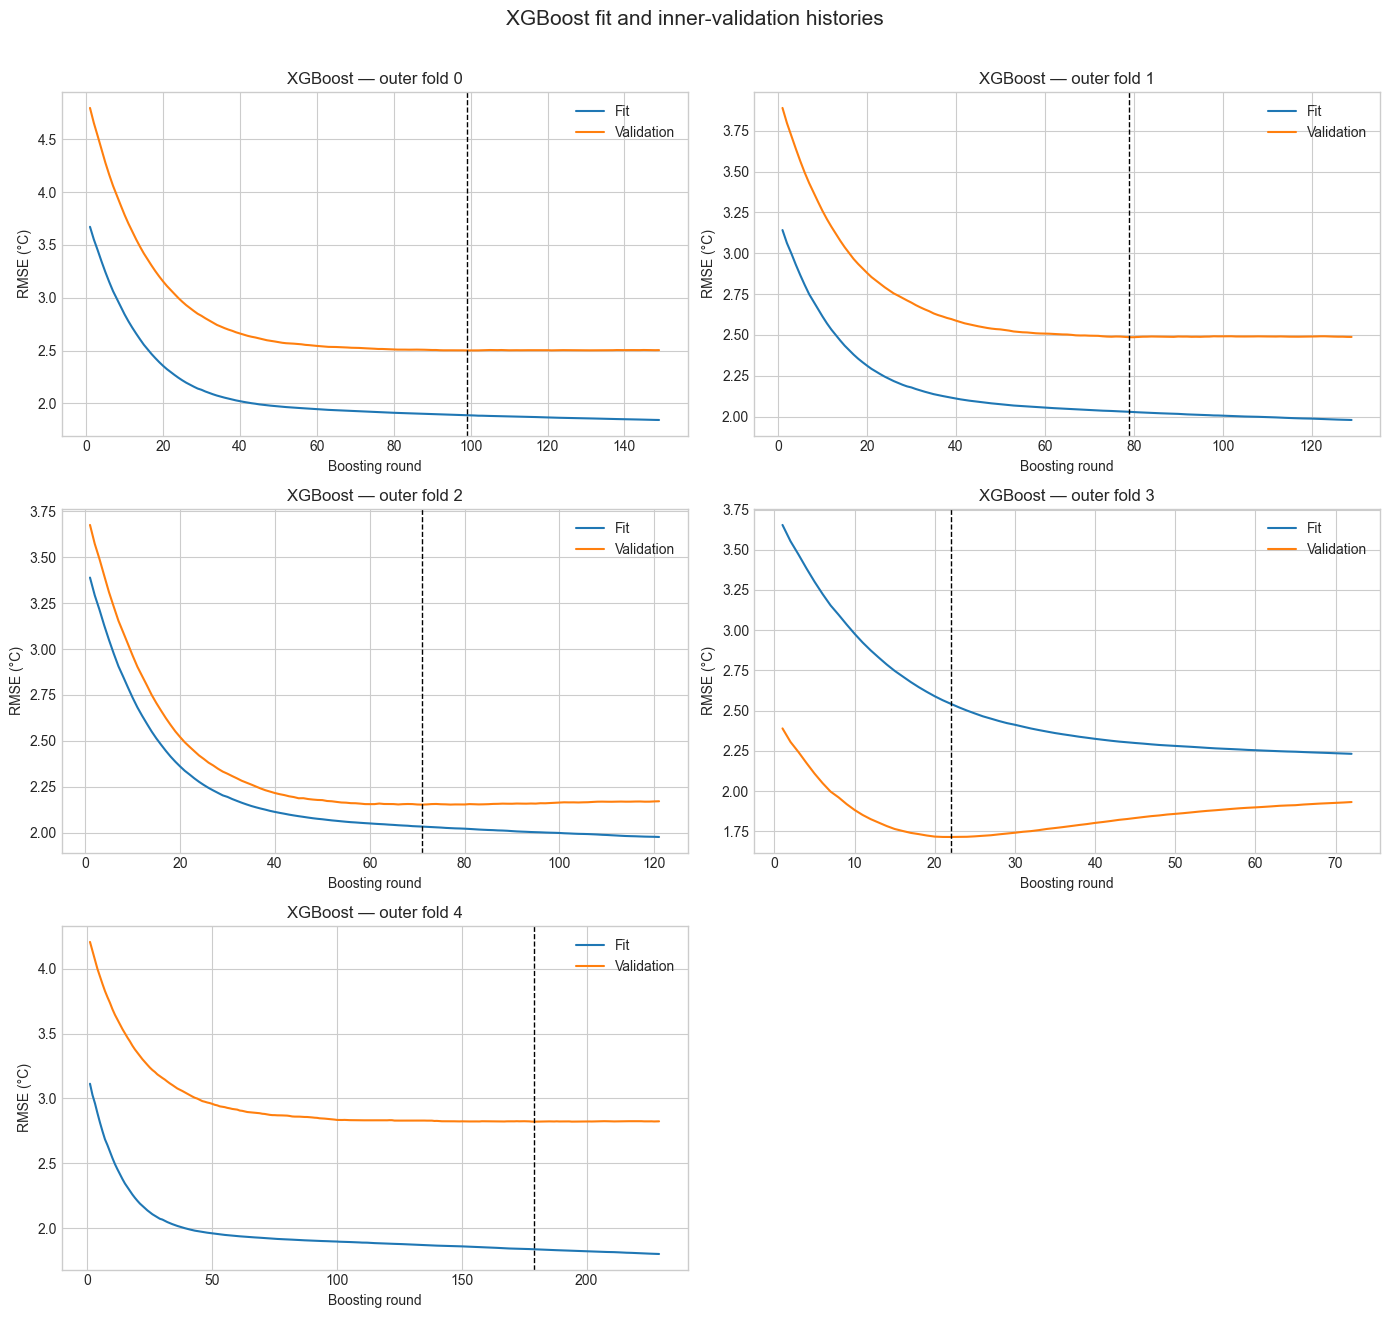

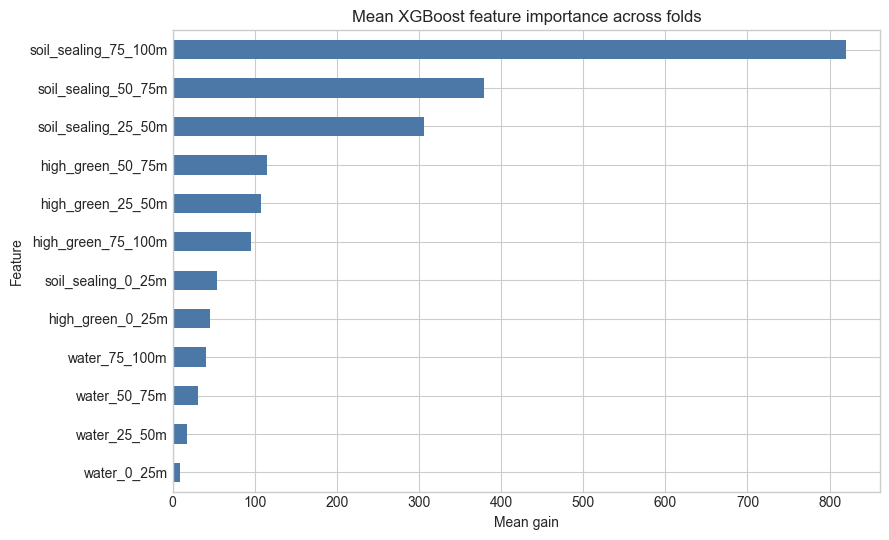

In [15]:
fig, axes = plt.subplots(3, 2, figsize=(14, 13))
for result, ax in zip(xgb_results, axes.flat):
    rounds = [item['round'] for item in result.history]
    ax.plot(rounds, [item['fit_rmse_c'] for item in result.history], label='Fit')
    ax.plot(rounds, [item['validation_rmse_c'] for item in result.history], label='Validation')
    ax.axvline(result.best_round, color='black', linestyle='--', linewidth=1)
    ax.set(
        title=f'XGBoost — outer fold {result.outer_fold}', xlabel='Boosting round',
        ylabel='RMSE (°C)',
    )
    ax.legend()
axes.flat[-1].axis('off')
fig.suptitle('XGBoost fit and inner-validation histories', y=1.01, fontsize=15)
plt.tight_layout()
plt.show()

mean_gain = pd.Series({
    name: np.mean([result.feature_importance_gain[name] for result in xgb_results])
    for name in feature_names
}).sort_values()
fig, ax = plt.subplots(figsize=(9, 5.5))
mean_gain.plot.barh(ax=ax, color='#4c78a8')
ax.set(title='Mean XGBoost feature importance across folds', xlabel='Mean gain', ylabel='Feature')
plt.tight_layout()
plt.show()

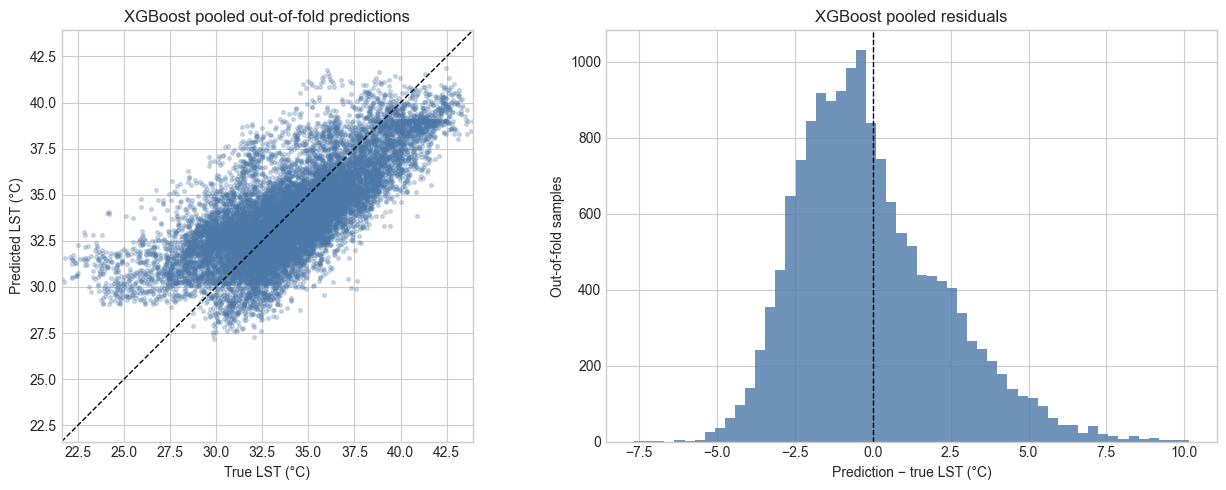

Completed five XGBoost folds on cuda; produced 15,389 unique out-of-fold predictions from 12 radial-band features.


In [16]:
plot_min = float(min(xgb_targets.min(), xgb_predictions.min()))
plot_max = float(max(xgb_targets.max(), xgb_predictions.max()))
xgb_residuals = xgb_predictions - xgb_targets
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].scatter(xgb_targets, xgb_predictions, s=7, alpha=0.25, color='#4c78a8')
axes[0].plot([plot_min, plot_max], [plot_min, plot_max], 'k--', linewidth=1)
axes[0].set(
    title='XGBoost pooled out-of-fold predictions', xlabel='True LST (°C)',
    ylabel='Predicted LST (°C)', xlim=(plot_min, plot_max), ylim=(plot_min, plot_max),
)
axes[0].set_aspect('equal', adjustable='box')
axes[1].hist(xgb_residuals, bins=55, color='#4c78a8', alpha=0.8)
axes[1].axvline(0, color='black', linestyle='--', linewidth=1)
axes[1].set(
    title='XGBoost pooled residuals', xlabel='Prediction − true LST (°C)',
    ylabel='Out-of-fold samples',
)
plt.tight_layout()
plt.show()
print(
    f'Completed five XGBoost folds on {xgb_device}; produced '
    f'{len(xgb_indices):,} unique out-of-fold predictions from 12 radial-band features.'
)